In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/deeplear final/PlantVillage"

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # делаем одинаковый размер
    transforms.ToTensor(),            # переводим в числа
    transforms.Normalize([0.5,0.5,0.5],
                         [0.5,0.5,0.5])  # нормализация
])

In [ ]:
dataset = datasets.ImageFolder(root=data_path, transform=transform)

print("Classes:", dataset.classes)
print("Num classes:", len(dataset.classes))
print("Total images:", len(dataset))

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Num classes: 15
Total images: 20638


In [ ]:
counter = Counter(dataset.targets)
print(counter)

Counter({12: 3208, 5: 2127, 7: 1909, 9: 1771, 10: 1676, 14: 1591, 1: 1478, 11: 1404, 2: 1000, 3: 1000, 6: 1000, 0: 997, 8: 952, 13: 373, 4: 152})


In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)

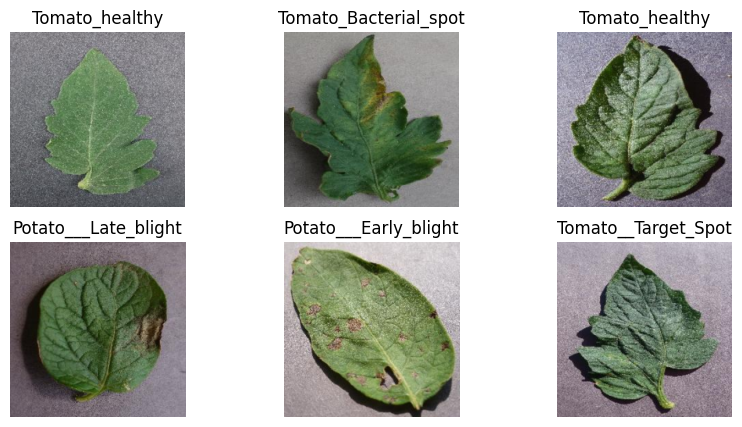

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)

    img = images[i].permute(1,2,0)
    img = img * 0.5 + 0.5

    plt.imshow(img)
    plt.title(dataset.classes[labels[i]])
    plt.axis("off")

plt.show()

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BaselineCNN(len(dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def train_one_epoch():
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)


def evaluate():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            _, pred = torch.max(out, 1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
#week3

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import json, time, os
from pathlib import Path
from collections import Counter

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report
)
from tqdm.notebook import tqdm

In [ ]:
#config
CFG = {
    "data_path":    "/content/drive/MyDrive/deeplear final/PlantVillage",
    "img_size":     128,      # 128 быстрее T4; поменяй на 224 если хочешь max качество
    "batch_size":   64,
    "epochs":       25,
    "lr":           1e-3,
    "weight_decay": 1e-4,
    "dropout":      0.4,
    "val_split":    0.2,
    "seed":         42,
    "num_workers":  2,        # Colab: 2 стабильнее
    "output_dir":   "/content/drive/MyDrive/deeplear final/outputs/week03",
}

Path(CFG["output_dir"]).mkdir(parents=True, exist_ok=True)

In [ ]:
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}  ({torch.cuda.get_device_name(0)})")

Device: cuda  (Tesla T4)


In [ ]:
#transform
S = CFG["img_size"]

train_transform = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomResizedCrop(S, scale=(0.75, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [ ]:
full_dataset = datasets.ImageFolder(root=CFG["data_path"])
class_names  = full_dataset.classes
num_classes  = len(class_names)

print(f"Classes: {num_classes}")
print(f"Total images: {len(full_dataset)}")
print(f"Class distribution: {dict(Counter(full_dataset.targets))}")

# Разбиваем индексы, применяем разные transforms
n_val   = int(len(full_dataset) * CFG["val_split"])
n_train = len(full_dataset) - n_val

train_idx, val_idx = torch.utils.data.random_split(
    range(len(full_dataset)), [n_train, n_val],
    generator=torch.Generator().manual_seed(CFG["seed"])
)

Classes: 15
Total images: 20638
Class distribution: {0: 997, 1: 1478, 2: 1000, 3: 1000, 4: 152, 5: 2127, 6: 1000, 7: 1909, 8: 952, 9: 1771, 10: 1676, 11: 1404, 12: 3208, 13: 373, 14: 1591}


In [ ]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        img, label = self.dataset.imgs[self.indices[i]]
        from PIL import Image
        img = Image.open(img).convert("RGB")
        return self.transform(img), label

train_ds = TransformSubset(full_dataset, train_idx.indices, train_transform)
val_ds   = TransformSubset(full_dataset, val_idx.indices,   val_transform)


In [ ]:
#weight sampler
train_labels = [full_dataset.targets[i] for i in train_idx.indices]
class_counts = np.bincount(train_labels)
sample_weights = 1.0 / class_counts[train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                          sampler=sampler, num_workers=CFG["num_workers"],
                          pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"],
                          pin_memory=True)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Train batches: 258  |  Val batches: 65


In [ ]:
#model
class ConvBlock(nn.Module):
    """Conv3×3 → BN → ReLU → Conv3×3 → BN → ReLU → MaxPool  (+Dropout2d)"""
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        return self.pool(self.drop(self.block(x)))

In [ ]:
class PlantCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        d = dropout
        self.features = nn.Sequential(
            ConvBlock(3,   32,  dropout=0.0),
            ConvBlock(32,  64,  dropout=d * 0.5),
            ConvBlock(64,  128, dropout=d * 0.5),
            ConvBlock(128, 256, dropout=d),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.gap(self.features(x)))

In [ ]:
model = PlantCNN(num_classes, dropout=CFG["dropout"]).to(device)

In [ ]:
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel: PlantCNN  |  params: {n_params:,}")


Model: PlantCNN  |  params: 1,312,495


In [ ]:
#loss
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)

scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=1e-6)

In [ ]:
def train_one_epoch():
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in tqdm(train_loader, desc="  train", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / len(train_loader), correct / total


In [ ]:
@torch.no_grad()
def evaluate():
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    for x, y in tqdm(val_loader, desc="  val  ", leave=False):
        x, y = x.to(device), y.to(device)
        out  = model(x)
        loss = criterion(out, y)

        preds = out.argmax(1)
        total_loss += loss.item()
        correct    += (preds == y).sum().item()
        total      += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    acc = correct / total
    f1  = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    return total_loss / len(val_loader), acc, f1, all_preds, all_labels

In [ ]:
history = {k: [] for k in
    ["train_loss","val_loss","train_acc","val_acc","val_f1","lr"]}

best_val_acc = 0.0
best_preds, best_labels = [], []
ckpt_path = Path(CFG["output_dir"]) / "best_model.pt"

print(f"\n{'─'*55}")
print(f"  Epoch   Tr-Loss   Val-Loss   Val-Acc   Val-F1   LR")
print(f"{'─'*55}")

t0 = time.time()


───────────────────────────────────────────────────────
  Epoch   Tr-Loss   Val-Loss   Val-Acc   Val-F1   LR
───────────────────────────────────────────────────────


In [ ]:
for epoch in range(1, CFG["epochs"] + 1):
    tr_loss, tr_acc = train_one_epoch()
    vl_loss, vl_acc, vl_f1, vl_preds, vl_labels = evaluate()
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(vl_f1)
    history["lr"].append(current_lr)

    marker = " ←" if vl_acc > best_val_acc else ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_preds, best_labels = vl_preds[:], vl_labels[:]
        torch.save({
            "epoch": epoch, "model_state": model.state_dict(),
            "val_acc": vl_acc, "val_f1": vl_f1,
            "classes": class_names, "config": CFG,
        }, ckpt_path)

    print(f"  {epoch:3d}/{CFG['epochs']}   "
          f"{tr_loss:.4f}    {vl_loss:.4f}     "
          f"{vl_acc:.4f}   {vl_f1:.4f}   "
          f"{current_lr:.1e}{marker}")


  train:   0%|          | 0/258 [00:00<?, ?it/s]

  val  :   0%|          | 0/65 [00:00<?, ?it/s]

    1/25   2.0298    1.6420     0.5561   0.5547   1.0e-03 ←


  train:   0%|          | 0/258 [00:00<?, ?it/s]

  val  :   0%|          | 0/65 [00:00<?, ?it/s]

...

  val  :   0%|          | 0/65 [00:00<?, ?it/s]

   24/25   0.7846    0.7155     0.9508   0.9511   1.7e-05


  train:   0%|          | 0/258 [00:00<?, ?it/s]

  val  :   0%|          | 0/65 [00:00<?, ?it/s]

   25/25   0.7787    0.7100     0.9530   0.9531   4.9e-06


In [ ]:
elapsed = time.time() - t0

In [ ]:
print(f"{'─'*55}")
print(f"Done in {elapsed/60:.1f} min  |  best val_acc = {best_val_acc:.4f}")

───────────────────────────────────────────────────────
Done in 94.3 min  |  best val_acc = 0.9549


In [ ]:
with open(Path(CFG["output_dir"]) / "history.json", "w") as f:
    json.dump(history, f, indent=2)

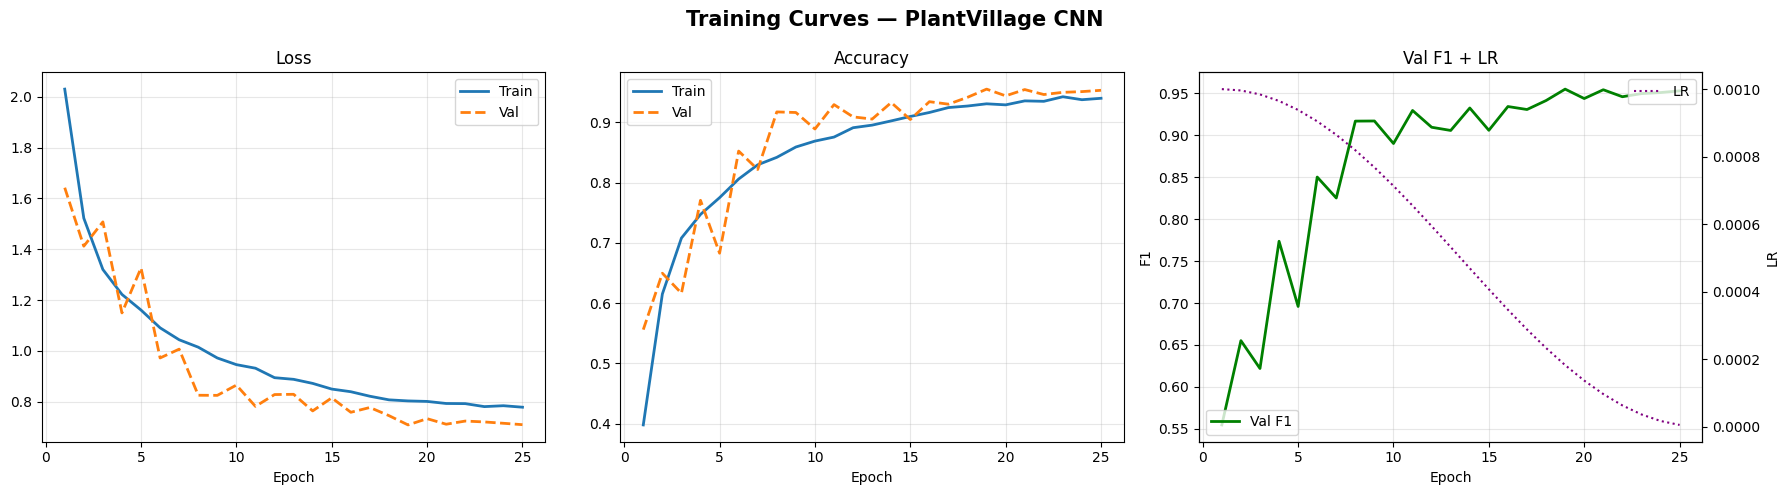

✓ loss_curves.png saved


In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Curves — PlantVillage CNN", fontsize=15, fontweight="bold")

axes[0].plot(epochs_range, history["train_loss"], label="Train", lw=2)
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   lw=2, ls="--")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train", lw=2)
axes[1].plot(epochs_range, history["val_acc"],   label="Val",   lw=2, ls="--")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

ax2 = axes[2].twinx()
axes[2].plot(epochs_range, history["val_f1"], label="Val F1",
             lw=2, color="green")
ax2.plot(epochs_range, history["lr"], label="LR",
         lw=1.5, color="purple", ls=":")
axes[2].set_title("Val F1 + LR"); axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1"); ax2.set_ylabel("LR")
axes[2].legend(loc="lower left"); ax2.legend(loc="upper right")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CFG["output_dir"]) / "loss_curves.png", dpi=150)
plt.show()
print("✓ loss_curves.png saved")

In [ ]:
report_dict = classification_report(
    best_labels, best_preds,
    target_names=class_names, output_dict=True, zero_division=0
)
per_f1 = {c: report_dict[c]["f1-score"] for c in class_names}
sorted_items = sorted(per_f1.items(), key=lambda x: x[1])
cls_names, cls_scores = zip(*sorted_items)

colors = ["#e74c3c" if s < 0.70 else "#f39c12" if s < 0.85 else "#27ae60"
          for s in cls_scores]


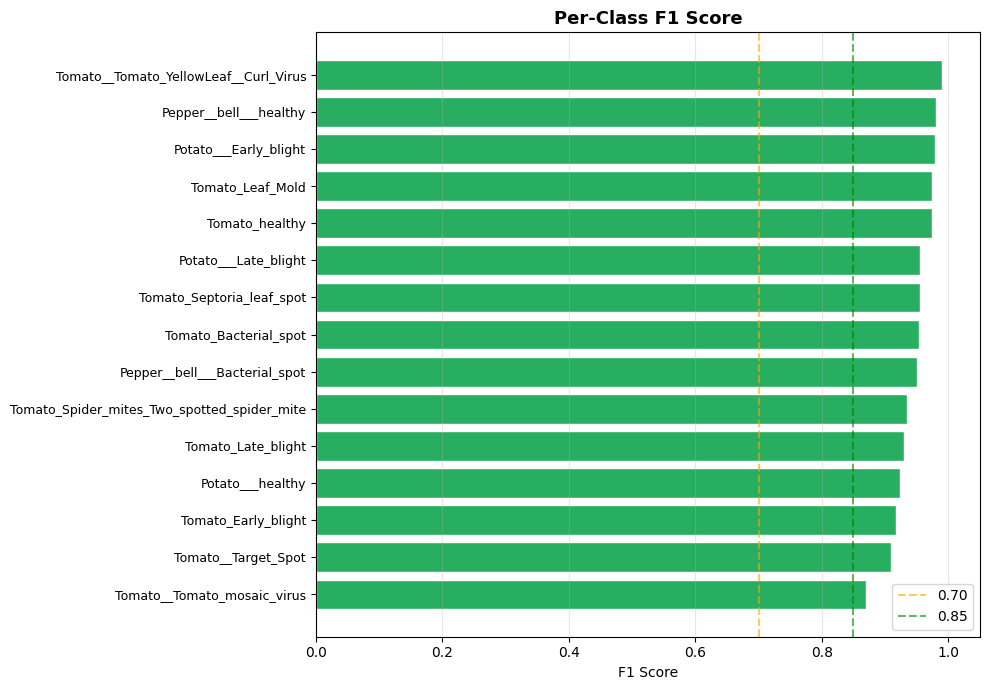

✓ per_class_f1.png saved


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(cls_names)), cls_scores, color=colors, edgecolor="white")
ax.set_yticks(range(len(cls_names)))
ax.set_yticklabels(cls_names, fontsize=9)
ax.set_xlabel("F1 Score")
ax.set_title("Per-Class F1 Score", fontsize=13, fontweight="bold")
ax.axvline(0.70, color="orange", ls="--", alpha=0.6, label="0.70")
ax.axvline(0.85, color="green",  ls="--", alpha=0.6, label="0.85")
ax.set_xlim(0, 1.05); ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(Path(CFG["output_dir"]) / "per_class_f1.png", dpi=150)
plt.show()
print("✓ per_class_f1.png saved")

In [ ]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(best_labels, best_preds,
                             target_names=class_names, zero_division=0))



CLASSIFICATION REPORT
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.91      0.95       188
                     Pepper__bell___healthy       0.99      0.97      0.98       307
                      Potato___Early_blight       0.98      0.98      0.98       214
                       Potato___Late_blight       0.94      0.98      0.96       211
                           Potato___healthy       0.86      1.00      0.92        30
                      Tomato_Bacterial_spot       0.97      0.93      0.95       448
                        Tomato_Early_blight       0.87      0.97      0.92       196
                         Tomato_Late_blight       0.98      0.88      0.93       361
                           Tomato_Leaf_Mold       0.95      1.00      0.97       191
                  Tomato_Septoria_leaf_spot       0.95      0.96      0.95       348
Tomato_Spider_mites_Two_spotted_spider_mi